<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da13_apt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab에서 한글 폰트 사용하기

## Step 1. Colab 런타임(리눅스 가상머신)에 한글 폰트 설치

In [ ]:
# Jupyter Notebook 코드 셀에서 리눅스 명령어를 실행
!sudo apt install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,765 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

*   `sudo apt install -y fonts-nanum`
    *   sudo: 관리자 권한으로 실행.
    *   apt: 리눅스 패키지(프로그램) 관리자. 설치, 삭제 등.
    *   install: 설치
    *   -y 옵션: 설치 중에 사용자에게 물어보는 질문들에 대해서 yes라고 답.
    *   fonts-name: 폰트 종류
*   `sudo fc-cache -fv`
    *   리눅스에서 새로운 폰트를 설치한 후, OS에서 설치된 폰트를 바로 인식할 수 있도록 폰트 캐시를 강제로 업데이트.
    *   font config cache(폰트 설정 캐시)
    *   -f 옵셔: 강제 적용.
*   `rm ~/.cache/matplotlib -rf`
    *   rm: remove. 파일 또는 디렉토리를 삭제.
    *   ~/.cache/matplotlib: 삭제할 폴더 경로.
    *   -rf 옵션: recursive, force. 모든 하위 폴더들을 강제로(파일 존재 여부에 상관 없이) 삭제.

## Step 2. Colab 런타임을 재시작

~/.cache 디렉토리 아래에 matplotlib 디렉토리가 새로 생성됨.

Colab 런타임에 새로 설치된 폰트가 matplotlib에 등록.

## Step 3. matplotlib.pyplot 모듈에서 설치한 한글 폰트를 사용할 수 있도록 설정

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

## 테스트

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.DataFrame(data={
    '시군구': ['서초구', '강남구', '송파구'],
    '가격': [9_000, 10_000, 9_500],
})
df

,시군구,가격
0,서초구,9000
1,강남구,10000
2,송파구,9500


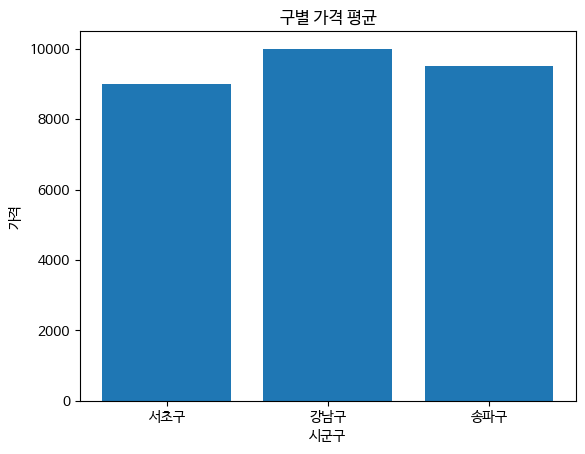

In [ ]:
plt.bar(x=df['시군구'], height=df['가격'])
plt.xlabel('시군구')
plt.ylabel('가격')
plt.title('구별 가격 평균')
plt.show()

# 아파트 실거래가 분석

*   [apt_202504.csv](https://github.com/JakeOh/202605_BD57/raw/refs/heads/main/datasets/apt_202504.csv) 파일을 읽고 DataFrame 생성
    *   첫 15줄은 파일 설명 문서 -> skip
    *   encoding 파라미터 설정(한글 인코딩: euc-kr)
    *   '가격' 컬럼에는 숫자 자릿수를 구분하는 comma가 사용되고 있음(예: 10,000)
        *   '가격' 컬럼은 숫자 타입이어야 함!
    *   일부 컬럼에서는 '-' 문자열이 NA(Not Available, 값이 없음)의 의미로 사용되고 있음.
        *   '-'는 NA로 대체.
*   데이터 프레임 파악
    *   info, head, tail, describe, dtypes, ...
*   '시군구' 컬럼의 값을 이용해서, province 파생 변수(광역시도)를 만듦.
    *   '인천광역시 부평구 부평동' -> '인천광역시'
    *   '충청남도 천안시 서북구' -> '충청남도'
*   '시군구' 컬럼의 값을 이용해서, county 파생 변수(시/군/구)를 만듦.
    *   '인천광역시 부평구 부평동' -> '부평구'
    *   '충청남도 천안시 서북구' -> '천안시'
*   '계약년월' 컬럼의 값을 이용해서, year(계약년도), month(계약월) 파생 변수 만듦.
    *   202504 -> 2025(year), 4(month)
*   서울특별시 아파트들의 구별 아파트 가격의 개수, 평균, 최솟값, 최댓값
*   광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값
*   면적이  $84 m^2$  이상  $100 m^2$  미만의 서울특별시 아파트들 중에서, 구별 아파트 가격 개수, 평균, 최솟값, 최댓값
*   면적이 $84 m^2$ 이상 $100 m^2$ 미만의 아파트들 중에서, 광역시도별 아파트 가격 개수, 평균, 최솟값, 최댓값
    *   결과를 평균의 내림차순으로 정렬해서 출력
    *   결과를 최댓값의 내림차순으로 정렬해서 출력
    *   결과를 최솟값의 오름차순으로 정렬해서 출력


# 데이터프레임 생성

In [ ]:
file_path = 'https://github.com/JakeOh/202605_BD57/raw/refs/heads/main/datasets/apt_202504.csv'

In [ ]:
apt = pd.read_csv(file_path,            # csv 파일 경로
                  encoding='euc-kr',    # csv 파일 인코딩 타입(utf-8 기본값)
                  skiprows=15,          # csv 파일에서 건너뛰어야 할 행의 개수
                  thousands=',',        # 숫자에서 천자리 구분자로 사용된 문자
                  na_values='-'         # null로 취급할 문자
                  )

In [ ]:
apt.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
0,1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,202504,30,17355,NaN,3,개인,개인,1983,길주남로90번길 45,NaN,중개거래,인천 부평구,NaN
1,2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,202504,30,57800,NaN,23,개인,개인,2023,인하로222번길 20,NaN,중개거래,인천 미추홀구,NaN
2,3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,202504,30,41000,NaN,22,개인,개인,2021,염전로 414,NaN,중개거래,인천 미추홀구,NaN
3,4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,202504,30,73850,2,15,개인,개인,1986,마장로42길 16,NaN,직거래,NaN,25.04.30
4,5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,202504,30,86200,NaN,20,개인,개인,1997,제기로 131,NaN,중개거래,서울 동대문구,NaN


In [ ]:
apt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36974 entries, 0 to 36973
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   NO        36974 non-null  int64  
 1   시군구       36974 non-null  object 
 2   번지        36973 non-null  object 
 3   본번        36974 non-null  int64  
 4   부번        36974 non-null  int64  
 5   단지명       36974 non-null  object 
 6   전용면적(㎡)   36974 non-null  float64
 7   계약년월      36974 non-null  int64  
 8   계약일       36974 non-null  int64  
 9   거래금액(만원)  36974 non-null  int64  
 10  동         5074 non-null   object 
 11  층         36974 non-null  int64  
 12  매수자       36974 non-null  object 
 13  매도자       36974 non-null  object 
 14  건축년도      36974 non-null  int64  
 15  도로명       36974 non-null  object 
 16  해제사유발생일   1191 non-null   float64
 17  거래유형      36974 non-null  object 
 18  중개사소재지    33763 non-null  object 
 19  등기일자      5659 non-null   object 
dtypes: float64(2), int64(8), obj

In [ ]:
apt[~apt['해제사유발생일'].isna()].head()

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
85,86,인천광역시 부평구 산곡동,307,307,0,현대1차,84.60,202504,30,37000,NaN,11,개인,개인,1985,경원대로 1269,20250430.0,중개거래,"인천 부평구, 인천 서구",NaN
208,209,서울특별시 성동구 마장동,784,784,0,세림,72.84,202504,30,97500,NaN,4,개인,개인,1986,마장로42길 16,20250430.0,중개거래,서울 성동구,NaN
376,377,인천광역시 서구 마전동,925,925,0,서해,59.67,202504,30,13300,NaN,5,개인,개인,1992,검단로487번안길 16,20250507.0,중개거래,인천 서구,NaN
405,406,경기도 동두천시 생연동,464-9,464,9,우성아파트,59.90,202504,30,6000,NaN,8,개인,개인,1992,송터로 21,20250507.0,중개거래,경기 연천군,NaN
495,496,경상북도 칠곡군 석적읍 중리,141,141,0,부영,49.89,202504,30,5700,NaN,18,개인,개인,2000,북중리3길 70,20250507.0,중개거래,경북 칠곡군,NaN


In [ ]:
apt[apt['해제사유발생일'].notna()].head()

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
85,86,인천광역시 부평구 산곡동,307,307,0,현대1차,84.60,202504,30,37000,NaN,11,개인,개인,1985,경원대로 1269,2025-04-30,중개거래,"인천 부평구, 인천 서구",NaT
208,209,서울특별시 성동구 마장동,784,784,0,세림,72.84,202504,30,97500,NaN,4,개인,개인,1986,마장로42길 16,2025-04-30,중개거래,서울 성동구,NaT
376,377,인천광역시 서구 마전동,925,925,0,서해,59.67,202504,30,13300,NaN,5,개인,개인,1992,검단로487번안길 16,2025-05-07,중개거래,인천 서구,NaT
405,406,경기도 동두천시 생연동,464-9,464,9,우성아파트,59.90,202504,30,6000,NaN,8,개인,개인,1992,송터로 21,2025-05-07,중개거래,경기 연천군,NaT
495,496,경상북도 칠곡군 석적읍 중리,141,141,0,부영,49.89,202504,30,5700,NaN,18,개인,개인,2000,북중리3길 70,2025-05-07,중개거래,경북 칠곡군,NaT


In [ ]:
apt['해제사유발생일'].unique()

array([      nan, 20250430., 20250507., 20250501., 20250506., 20250502.,
       20250504., 20250429., 20250508., 20250505., 20250428., 20250425.,
       20250426., 20250424., 20250503., 20250422., 20250423., 20250421.,
       20250420., 20250427., 20250419., 20250418., 20250417., 20250416.,
       20250415., 20250414., 20250413., 20250412., 20250411., 20250410.,
       20250409., 20250408., 20250407., 20250406., 20250405., 20250404.,
       20250403., 20250402., 20250401.])

In [ ]:
# 해제사유발생일 컬럼을 날짜/시간 타입(datetime)으로 변환
apt['해제사유발생일'] = pd.to_datetime(apt['해제사유발생일'], format='%Y%m%d')

In [ ]:
apt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36974 entries, 0 to 36973
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   NO        36974 non-null  int64         
 1   시군구       36974 non-null  object        
 2   번지        36973 non-null  object        
 3   본번        36974 non-null  int64         
 4   부번        36974 non-null  int64         
 5   단지명       36974 non-null  object        
 6   전용면적(㎡)   36974 non-null  float64       
 7   계약년월      36974 non-null  int64         
 8   계약일       36974 non-null  int64         
 9   거래금액(만원)  36974 non-null  int64         
 10  동         5074 non-null   object        
 11  층         36974 non-null  int64         
 12  매수자       36974 non-null  object        
 13  매도자       36974 non-null  object        
 14  건축년도      36974 non-null  int64         
 15  도로명       36974 non-null  object        
 16  해제사유발생일   1191 non-null   datetime64[ns]
 17  거래유형      36

In [ ]:
apt['해제사유발생일'].unique()

<DatetimeArray>
[                'NaT', '2025-04-30 00:00:00', '2025-05-07 00:00:00',
 '2025-05-01 00:00:00', '2025-05-06 00:00:00', '2025-05-02 00:00:00',
 '2025-05-04 00:00:00', '2025-04-29 00:00:00', '2025-05-08 00:00:00',
 '2025-05-05 00:00:00', '2025-04-28 00:00:00', '2025-04-25 00:00:00',
 '2025-04-26 00:00:00', '2025-04-24 00:00:00', '2025-05-03 00:00:00',
 '2025-04-22 00:00:00', '2025-04-23 00:00:00', '2025-04-21 00:00:00',
 '2025-04-20 00:00:00', '2025-04-27 00:00:00', '2025-04-19 00:00:00',
 '2025-04-18 00:00:00', '2025-04-17 00:00:00', '2025-04-16 00:00:00',
 '2025-04-15 00:00:00', '2025-04-14 00:00:00', '2025-04-13 00:00:00',
 '2025-04-12 00:00:00', '2025-04-11 00:00:00', '2025-04-10 00:00:00',
 '2025-04-09 00:00:00', '2025-04-08 00:00:00', '2025-04-07 00:00:00',
 '2025-04-06 00:00:00', '2025-04-05 00:00:00', '2025-04-04 00:00:00',
 '2025-04-03 00:00:00', '2025-04-02 00:00:00', '2025-04-01 00:00:00']
Length: 39, dtype: datetime64[ns]

In [ ]:
apt['등기일자'].unique()

array([nan, '25.04.30', '25.05.01', '25.05.02', '25.04.29', '25.04.28',
       '25.04.25', '25.04.24', '25.04.23', '25.04.22', '25.04.21',
       '25.04.18', '25.04.17', '25.04.16', '25.04.15', '25.04.14',
       '25.04.11', '25.04.10', '25.04.09', '25.04.08', '25.04.07',
       '25.04.04', '25.04.03', '25.04.02', '25.04.01'], dtype=object)

In [ ]:
# 등기일자 컬럼을 날짜/시간 타입으로 변환
apt['등기일자'] = pd.to_datetime(apt['등기일자'], format='%y.%m.%d')

In [ ]:
apt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36974 entries, 0 to 36973
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   NO        36974 non-null  int64         
 1   시군구       36974 non-null  object        
 2   번지        36973 non-null  object        
 3   본번        36974 non-null  int64         
 4   부번        36974 non-null  int64         
 5   단지명       36974 non-null  object        
 6   전용면적(㎡)   36974 non-null  float64       
 7   계약년월      36974 non-null  int64         
 8   계약일       36974 non-null  int64         
 9   거래금액(만원)  36974 non-null  int64         
 10  동         5074 non-null   object        
 11  층         36974 non-null  int64         
 12  매수자       36974 non-null  object        
 13  매도자       36974 non-null  object        
 14  건축년도      36974 non-null  int64         
 15  도로명       36974 non-null  object        
 16  해제사유발생일   1191 non-null   datetime64[ns]
 17  거래유형      36

In [ ]:
apt['등기일자'].unique()

<DatetimeArray>
[                'NaT', '2025-04-30 00:00:00', '2025-05-01 00:00:00',
 '2025-05-02 00:00:00', '2025-04-29 00:00:00', '2025-04-28 00:00:00',
 '2025-04-25 00:00:00', '2025-04-24 00:00:00', '2025-04-23 00:00:00',
 '2025-04-22 00:00:00', '2025-04-21 00:00:00', '2025-04-18 00:00:00',
 '2025-04-17 00:00:00', '2025-04-16 00:00:00', '2025-04-15 00:00:00',
 '2025-04-14 00:00:00', '2025-04-11 00:00:00', '2025-04-10 00:00:00',
 '2025-04-09 00:00:00', '2025-04-08 00:00:00', '2025-04-07 00:00:00',
 '2025-04-04 00:00:00', '2025-04-03 00:00:00', '2025-04-02 00:00:00',
 '2025-04-01 00:00:00']
Length: 25, dtype: datetime64[ns]

In [ ]:
apt.head()

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
0,1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,202504,30,17355,NaN,3,개인,개인,1983,길주남로90번길 45,NaT,중개거래,인천 부평구,NaT
1,2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,202504,30,57800,NaN,23,개인,개인,2023,인하로222번길 20,NaT,중개거래,인천 미추홀구,NaT
2,3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,202504,30,41000,NaN,22,개인,개인,2021,염전로 414,NaT,중개거래,인천 미추홀구,NaT
3,4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,202504,30,73850,2,15,개인,개인,1986,마장로42길 16,NaT,직거래,NaN,2025-04-30
4,5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,202504,30,86200,NaN,20,개인,개인,1997,제기로 131,NaT,중개거래,서울 동대문구,NaT


In [ ]:
apt.tail()

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
36969,36970,경기도 안산시 상록구 사동,1639,1639,0,그랑시티자이2차,84.9921,202504,1,69000,NaN,27,개인,개인,2020,해양5로 17,NaT,중개거래,"경기 시흥시, 경기 안산시 상록구",NaT
36970,36971,경기도 안산시 상록구 사동,1639,1639,0,그랑시티자이2차,84.9712,202504,1,68000,NaN,5,개인,개인,2020,해양5로 17,NaT,중개거래,"경기 안산시 상록구, 서울 구로구",NaT
36971,36972,경기도 안산시 상록구 사동,1506,1506,0,본오,38.1300,202504,1,12400,NaN,4,개인,개인,1992,선진로 108,NaT,중개거래,경기 안산시 상록구,NaT
36972,36973,경기도 성남시 분당구 야탑동,156,156,0,목련마을(영남),84.9300,202504,1,86500,NaN,12,개인,개인,1995,판교로 669,NaT,중개거래,경기 성남시 분당구,NaT
36973,36974,울산광역시 동구 전하동,682-1,682,1,삼전아이필하모니,84.5300,202504,1,21500,NaN,15,개인,개인,2006,방어진순환도로 733,NaT,중개거래,울산 동구,NaT


`pandas.read_csv()` 함수의 파라미터를 설정해서 날짜로 취급할 컬럼의 날짜 포맷을 설정

In [ ]:
apt = pd.read_csv(file_path, encoding='euc-kr',
                  skiprows=15, thousands=',', na_values='-',
                  parse_dates=['해제사유발생일', '등기일자'],  # 날짜 타입으로 설정할 컬럼 이름(list)
                  date_format={'해제사유발생일': '%Y%m%d',
                               '등기일자': '%y.%m.%d'}         # 각 컬럼의 날짜 포맷(dict)
                  )

In [ ]:
apt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36974 entries, 0 to 36973
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   NO        36974 non-null  int64         
 1   시군구       36974 non-null  object        
 2   번지        36973 non-null  object        
 3   본번        36974 non-null  int64         
 4   부번        36974 non-null  int64         
 5   단지명       36974 non-null  object        
 6   전용면적(㎡)   36974 non-null  float64       
 7   계약년월      36974 non-null  int64         
 8   계약일       36974 non-null  int64         
 9   거래금액(만원)  36974 non-null  int64         
 10  동         5074 non-null   object        
 11  층         36974 non-null  int64         
 12  매수자       36974 non-null  object        
 13  매도자       36974 non-null  object        
 14  건축년도      36974 non-null  int64         
 15  도로명       36974 non-null  object        
 16  해제사유발생일   1191 non-null   datetime64[ns]
 17  거래유형      36

In [ ]:
apt.head(n=10)

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
0,1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,202504,30,17355,NaN,3,개인,개인,1983,길주남로90번길 45,NaT,중개거래,인천 부평구,NaT
1,2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,202504,30,57800,NaN,23,개인,개인,2023,인하로222번길 20,NaT,중개거래,인천 미추홀구,NaT
2,3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,202504,30,41000,NaN,22,개인,개인,2021,염전로 414,NaT,중개거래,인천 미추홀구,NaT
3,4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,202504,30,73850,2,15,개인,개인,1986,마장로42길 16,NaT,직거래,NaN,2025-04-30
4,5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,202504,30,86200,NaN,20,개인,개인,1997,제기로 131,NaT,중개거래,서울 동대문구,NaT
5,6,대구광역시 달서구 월성동,89,89,0,서한맨션,84.8100,202504,30,20000,NaN,12,개인,개인,1992,학산로 15,NaT,중개거래,대구 달서구,NaT
6,7,대구광역시 달성군 구지면 응암리,1251,1251,0,대구국가산단반도유보라아이비파크2,74.9638,202504,30,18200,NaN,14,개인,개인,2020,국가산단북로60길 59,NaT,중개거래,대구 달성군,NaT
7,8,서울특별시 송파구 잠실동,44,44,0,레이크팰리스,84.8200,202504,30,262000,NaN,23,개인,개인,2006,잠실로 88,NaT,중개거래,"서울 광진구, 서울 송파구",NaT
8,9,인천광역시 중구 항동7가,27-107,27,107,라이프비취1차,72.7300,202504,30,14000,NaN,7,개인,개인,1980,축항대로86번길 47,NaT,중개거래,인천 중구,NaT
9,10,부산광역시 북구 만덕동,962,962,0,이편한세상금정산,84.9378,202504,30,46200,NaN,20,개인,개인,2021,상학로 36,NaT,중개거래,부산 북구,NaT


In [38]:
# 사용하기 불편한 컬럼 이름들을 간단히 변경
apt.rename(
    columns={'전용면적(㎡)': '전용면적', '거래금액(만원)': '거래금액'},
    inplace=True  # 원본 데이터프레임을 변경
)

In [39]:
apt.head(n=10)

,NO,시군구,번지,본번,부번,단지명,전용면적,계약년월,계약일,거래금액,동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
0,1,인천광역시 부평구 부평동,140-6,140,6,신영(1동2동),48.0100,202504,30,17355,NaN,3,개인,개인,1983,길주남로90번길 45,NaT,중개거래,인천 부평구,NaT
1,2,인천광역시 미추홀구 주안동,1662,1662,0,주안파크자이더플래티넘,84.9937,202504,30,57800,NaN,23,개인,개인,2023,인하로222번길 20,NaT,중개거래,인천 미추홀구,NaT
2,3,인천광역시 미추홀구 주안동,1628,1628,0,주안역센트레빌,59.9813,202504,30,41000,NaN,22,개인,개인,2021,염전로 414,NaT,중개거래,인천 미추홀구,NaT
3,4,서울특별시 성동구 마장동,784,784,0,세림,84.9300,202504,30,73850,2,15,개인,개인,1986,마장로42길 16,NaT,직거래,NaN,2025-04-30
4,5,서울특별시 동대문구 청량리동,60,60,0,한신,114.9500,202504,30,86200,NaN,20,개인,개인,1997,제기로 131,NaT,중개거래,서울 동대문구,NaT
5,6,대구광역시 달서구 월성동,89,89,0,서한맨션,84.8100,202504,30,20000,NaN,12,개인,개인,1992,학산로 15,NaT,중개거래,대구 달서구,NaT
6,7,대구광역시 달성군 구지면 응암리,1251,1251,0,대구국가산단반도유보라아이비파크2,74.9638,202504,30,18200,NaN,14,개인,개인,2020,국가산단북로60길 59,NaT,중개거래,대구 달성군,NaT
7,8,서울특별시 송파구 잠실동,44,44,0,레이크팰리스,84.8200,202504,30,262000,NaN,23,개인,개인,2006,잠실로 88,NaT,중개거래,"서울 광진구, 서울 송파구",NaT
8,9,인천광역시 중구 항동7가,27-107,27,107,라이프비취1차,72.7300,202504,30,14000,NaN,7,개인,개인,1980,축항대로86번길 47,NaT,중개거래,인천 중구,NaT
9,10,부산광역시 북구 만덕동,962,962,0,이편한세상금정산,84.9378,202504,30,46200,NaN,20,개인,개인,2021,상학로 36,NaT,중개거래,부산 북구,NaT


In [41]:
# 전용면적, 거래금액, 건축년도 기술 통계량
apt[['전용면적', '거래금액', '건축년도']].describe()

,전용면적,거래금액,건축년도
count,36974.000000,3.697400e+04,36974.000000
mean,73.912814,4.348493e+04,2006.137664
std,22.468251,4.163910e+04,10.891869
min,12.210000,1.200000e+03,1962.000000
25%,59.840000,1.820000e+04,1997.000000
50%,75.532800,3.370000e+04,2006.000000
75%,84.950000,5.550000e+04,2017.000000
max,244.470000,1.050000e+06,2025.000000


In [42]:
# 거래금액 최솟값 또는 최댓값인 행
apt[(apt['거래금액'] == apt['거래금액'].min()) |
    (apt['거래금액'] == apt['거래금액'].max())]

,NO,시군구,번지,본번,부번,단지명,전용면적,계약년월,계약일,거래금액,동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
7430,7431,서울특별시 강남구 압구정동,369-1,369,1,"현대2차(10,11,20,23,24,25동)",198.41,202504,23,1050000,NaN,9,개인,개인,1976,압구정로29길 71,NaT,중개거래,서울 강남구,NaT
7698,7699,전라남도 고흥군 도화면 당오리,487,487,0,뉴코아,22.68,202504,23,1200,NaN,3,개인,개인,1997,동신길 70,NaT,직거래,NaN,NaT
9811,9812,전라남도 고흥군 도화면 당오리,487,487,0,뉴코아,22.68,202504,21,1200,NaN,3,개인,개인,1997,동신길 70,NaT,직거래,NaN,2025-04-29


In [43]:
apt['매수자'].value_counts()

,count
매수자,
개인,36414
법인,362
공공기관,158
기타,40


In [44]:
apt['매도자'].value_counts()

,count
매도자,
개인,35590
법인,1301
기타,50
공공기관,33


In [45]:
apt['거래유형'].value_counts()

,count
거래유형,
중개거래,33765
직거래,3209


# 전용면적 분석

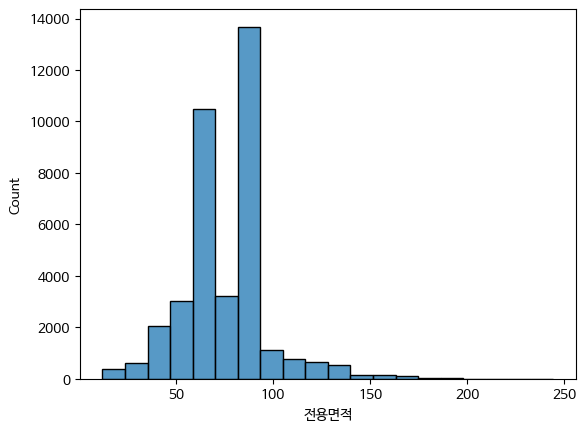

In [47]:
sns.histplot(data=apt, x='전용면적', bins=20)
plt.show()

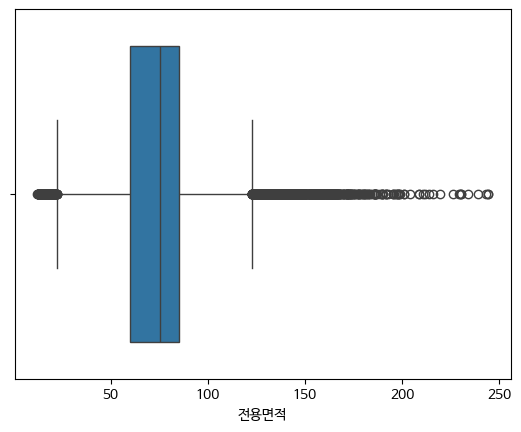

In [48]:
sns.boxplot(data=apt, x='전용면적')
plt.show()

# 거래 금액

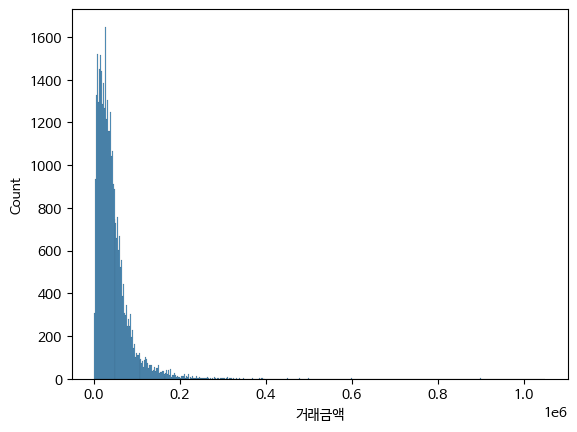

In [49]:
sns.histplot(data=apt, x='거래금액')
plt.show()

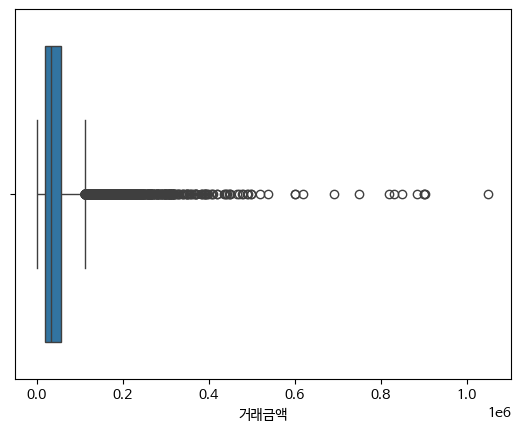

In [50]:
sns.boxplot(data=apt, x='거래금액')
plt.show()